# 07 - Pseudo-Label Generation v2 (GradCAM++ Multi-Scale)

Cải tiến so với notebook 04:
- **GradCAM++** thay GradCAM gốc (better localization cho multiple small spots)
- **Multi-scale fusion**: kết hợp features block 6 (14×14) + block 8 (7×7)
- **Adaptive Otsu threshold** thay fixed=0.5 (per-image)
- **Connected component filtering**: loại bỏ noise nhỏ < 50px
- **Toàn bộ training set** (~620 ảnh/lớp thay vì 100)
- Output: `pseudo_labels_v2_train/` + `processed_v2_train/`

In [3]:
import os
import sys

notebook_dir = os.path.abspath('')
proj_root = os.path.dirname(notebook_dir) if os.path.basename(notebook_dir) == 'notebooks' else notebook_dir
sys.path.insert(0, proj_root)
sys.path.insert(0, os.path.join(proj_root, 'utils'))

import torch
import torch.nn as nn
import numpy as np
import cv2
import json
import glob
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from PIL import Image
from collections import defaultdict
from torchvision import transforms

from utils.models import EfficientNetClassifier

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('proj_root:', proj_root)

device: cuda
proj_root: e:\Master\thesis-clean


## 1) Load data + model — TẤT CẢ ảnh train (không giới hạn 100)

In [4]:
train_dir = os.path.join(proj_root, 'notebooks', 'data', 'raw', 'train')
if not os.path.exists(train_dir):
    train_dir = 'data/raw/train'

class_dirs = sorted([d for d in Path(train_dir).iterdir() if d.is_dir()])
class_names = [d.name for d in class_dirs]
class_to_idx = {name: i for i, name in enumerate(class_names)}
idx_to_class = {i: name for name, i in class_to_idx.items()}
num_classes = len(class_names)

print(f'Classes ({num_classes}):', class_names)

# KHÁC NB04: lấy TẤT CẢ ảnh, không giới hạn 100/lớp
selected_samples = []
for cls_dir in class_dirs:
    cls_name = cls_dir.name
    cls_idx  = class_to_idx[cls_name]
    imgs = sorted(list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.png')))
    for img_path in imgs:
        selected_samples.append((str(img_path), cls_idx, cls_name))
    print(f'  {cls_name}: {len(imgs)} ảnh')

print(f'\nTổng: {len(selected_samples)} ảnh  (nb04 chỉ dùng 500)')

Classes (5): ['ALGAL_LEAF_SPOT', 'ALLOCARIDARA_ATTACK', 'HEALTHY_LEAF', 'LEAF_BLIGHT', 'PHOMOPSIS_LEAF_SPOT']
  ALGAL_LEAF_SPOT: 513 ảnh
  ALLOCARIDARA_ATTACK: 639 ảnh
  HEALTHY_LEAF: 683 ảnh
  LEAF_BLIGHT: 655 ảnh
  PHOMOPSIS_LEAF_SPOT: 614 ảnh

Tổng: 3104 ảnh  (nb04 chỉ dùng 500)


In [ ]:
model = EfficientNetClassifier(num_classes=num_classes, backbone='efficientnet_b0', pretrained=False)

ckpt_patterns = [
    os.path.join(proj_root, 'notebooks', 'models', 'classification', 'checkpoints', '*.pth'),
    'notebooks/models/classification/checkpoints/*.pth',
]
candidates = []
for pat in ckpt_patterns:
    candidates.extend(glob.glob(pat))

if not candidates:
    raise FileNotFoundError('Không tìm thấy checkpoint. Chạy notebook 02 trước.')

ckpt_path = max(candidates, key=os.path.getctime)
checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device).eval()
print('Loaded checkpoint:', ckpt_path)

## 2) GradCAM++ Multi-Scale setup

- **Layer fine** (`features.6`, 14×14): bắt spot nhỏ tốt hơn
- **Layer coarse** (`features.8`, 7×7): semantic context
- **GradCAM++** weights: dùng second-order gradient approximation
- **Fusion**: weighted sum (0.6 × fine + 0.4 × coarse)

In [6]:
def get_last_conv_in_block(model, block_idx):
    """Lấy tên Conv2d cuối cùng trong features block chỉ định."""
    prefix = f'base.features.{block_idx}'
    candidates = []
    for name, module in model.named_modules():
        if name.startswith(prefix) and isinstance(module, nn.Conv2d):
            candidates.append(name)
    if not candidates:
        raise ValueError(f'Không tìm thấy Conv2d trong {prefix}')
    return candidates[-1]

layer6_name = get_last_conv_in_block(model, 6)  # 14×14 resolution
layer8_name = get_last_conv_in_block(model, 8)  # 7×7  resolution

print('Layer fine  (features.6):', layer6_name)
print('Layer coarse(features.8):', layer8_name)

Layer fine  (features.6): base.features.6.3.block.3.0
Layer coarse(features.8): base.features.8.0


In [7]:
class MultiScaleGradCAMpp:
    """
    GradCAM++ trên 2 layer (fine 14×14 + coarse 7×7), fuse bằng weighted sum.
    GradCAM++ weights dùng second-order gradient approximation (tốt hơn GradCAM
    cho bệnh có nhiều đốm nhỏ vì không bị average-out).
    """

    def __init__(self, model, layer_fine_name, layer_coarse_name, device, weight_fine=0.6):
        self.model = model.to(device)
        self.model.eval()
        self.device = device
        self.weight_fine   = weight_fine
        self.weight_coarse = 1.0 - weight_fine

        modules = dict(model.named_modules())
        self.layer_fine   = modules[layer_fine_name]
        self.layer_coarse = modules[layer_coarse_name]

        self.activations = {}
        self.gradients   = {}

        self.layer_fine.register_forward_hook(self._activation_hook('fine'))
        self.layer_fine.register_full_backward_hook(self._gradient_hook('fine'))
        self.layer_coarse.register_forward_hook(self._activation_hook('coarse'))
        self.layer_coarse.register_full_backward_hook(self._gradient_hook('coarse'))

    def _activation_hook(self, name):
        def hook(module, inp, out):
            self.activations[name] = out.detach().cpu()
        return hook

    def _gradient_hook(self, name):
        def hook(module, grad_in, grad_out):
            self.gradients[name] = grad_out[0].detach().cpu()
        return hook

    def _gradcampp_single(self, act_tensor, grad_tensor, out_size):
        """Tính GradCAM++ map từ activations + gradients của 1 layer."""
        act  = act_tensor[0].numpy()   # [C, H, W]
        grad = grad_tensor[0].numpy()  # [C, H, W]

        eps   = 1e-7
        grad2 = grad ** 2
        grad3 = grad ** 3
        # sum activations per channel  → [C, 1, 1]
        sum_act = np.sum(act, axis=(1, 2), keepdims=True)
        denom   = 2.0 * grad2 + sum_act * grad3 + eps
        alpha   = grad2 / denom                                     # [C, H, W]
        weights = np.sum(alpha * np.maximum(grad, 0), axis=(1, 2))  # [C]

        cam = np.sum(weights[:, None, None] * act, axis=0)  # [H, W]
        cam = np.maximum(cam, 0)

        cam = cv2.resize(cam, out_size)  # (W, H)
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        return cam

    def generate(self, input_tensor, target_class):
        input_tensor = input_tensor.to(self.device)
        self.activations.clear()
        self.gradients.clear()

        self.model.zero_grad()
        output     = self.model(input_tensor)
        pred_class = output.argmax(dim=1).item()
        confidence = torch.softmax(output, dim=1)[0, target_class].item()

        output[0, target_class].backward()

        W, H = input_tensor.shape[3], input_tensor.shape[2]

        cam_fine   = self._gradcampp_single(self.activations['fine'],   self.gradients['fine'],   (W, H))
        cam_coarse = self._gradcampp_single(self.activations['coarse'], self.gradients['coarse'], (W, H))

        fused = self.weight_fine * cam_fine + self.weight_coarse * cam_coarse
        if fused.max() > fused.min():
            fused = (fused - fused.min()) / (fused.max() - fused.min())

        return fused, confidence, pred_class

In [8]:
gradcam_v2 = MultiScaleGradCAMpp(
    model=model,
    layer_fine_name=layer6_name,
    layer_coarse_name=layer8_name,
    device=device,
    weight_fine=0.6,
)

infer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print('MultiScale GradCAM++ ready')
print(f'  fine layer  : {layer6_name}')
print(f'  coarse layer: {layer8_name}')
print(f'  fusion      : 0.6 × fine + 0.4 × coarse')

MultiScale GradCAM++ ready
  fine layer  : base.features.6.3.block.3.0
  coarse layer: base.features.8.0
  fusion      : 0.6 × fine + 0.4 × coarse


## 3) Improved mask pipeline: Otsu threshold + CC filter

In [9]:
def adaptive_threshold_otsu(cam_map):
    """Otsu per-image — tốt hơn fixed 0.5 vì tự điều chỉnh theo distribution."""
    cam_u8 = (cam_map * 255).astype(np.uint8)
    _, mask = cv2.threshold(cam_u8, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return mask.astype(np.uint8)


def filter_connected_components(mask, min_area=50):
    """Giữ lại connected components có diện tích >= min_area pixel."""
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
    filtered = np.zeros_like(mask)
    for i in range(1, num_labels):  # 0 là background
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            filtered[labels == i] = 1
    return filtered


def create_pseudo_mask_v2(heatmap, min_cc_area=50):
    """Pipeline: Otsu → Morphological (ellipse kernel) → CC filter."""
    # 1) Adaptive threshold
    mask = adaptive_threshold_otsu(heatmap)

    # 2) Morphological: ellipse kernel tốt hơn rect cho vùng tròn như đốm lá
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)  # lấp lỗ hổng
    mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel)  # xóa noise nhỏ

    # 3) CC filtering
    mask = filter_connected_components(mask, min_area=min_cc_area)
    return mask.astype(np.uint8)


print('Helper functions ready')

Helper functions ready


## 4) Generate v2 pseudo labels — toàn bộ training set

In [10]:
pseudo_dir_v2    = Path(os.path.join(proj_root, 'notebooks', 'data', 'pseudo_labels_v2_train'))
processed_dir_v2 = Path(os.path.join(proj_root, 'notebooks', 'data', 'processed_v2_train'))
pseudo_dir_v2.mkdir(parents=True, exist_ok=True)
processed_dir_v2.mkdir(parents=True, exist_ok=True)

stats_v2           = []
results_by_class_v2 = defaultdict(list)
MAX_VIZ_PER_CLASS  = 10  # giới hạn RAM cho visualization

for img_path, cls_idx, cls_name in tqdm(selected_samples, desc='GradCAM++ v2'):
    try:
        orig_img = Image.open(img_path).convert('RGB').resize((224, 224))
        orig_arr = np.array(orig_img)

        input_tensor = infer_transform(orig_img).unsqueeze(0)

        heatmap, confidence, pred_class = gradcam_v2.generate(input_tensor, cls_idx)

        mask = create_pseudo_mask_v2(heatmap, min_cc_area=50)

        fname     = Path(img_path).name
        base_name = f'{cls_name}_{fname}'

        # Lưu mask
        cv2.imwrite(str(pseudo_dir_v2 / f'{base_name}_pseudo.png'),
                    (mask * 255).astype(np.uint8))
        # Lưu ảnh gốc
        orig_img.save(str(processed_dir_v2 / base_name))

        stats_v2.append({
            'filename':      base_name,
            'original_path': img_path,
            'class_name':    cls_name,
            'class_idx':     cls_idx,
            'pred_class':    pred_class,
            'confidence':    float(confidence),
            'mask_coverage': float(mask.mean()),
        })

        # Lưu data để viz (chỉ giữ MAX_VIZ_PER_CLASS đầu mỗi lớp)
        if len(results_by_class_v2[cls_name]) < MAX_VIZ_PER_CLASS:
            heatmap_colored = cv2.applyColorMap((heatmap * 255).astype(np.uint8), cv2.COLORMAP_JET)
            heatmap_rgb     = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
            gradcam_overlay = cv2.addWeighted(orig_arr, 0.6, heatmap_rgb, 0.4, 0)
            mask_rgb        = np.zeros_like(orig_arr)
            mask_rgb[:, :, 1] = mask * 255
            pseudo_overlay  = cv2.addWeighted(orig_arr, 0.7, mask_rgb, 0.3, 0)
            results_by_class_v2[cls_name].append({
                'orig_arr':       orig_arr,
                'heatmap':        heatmap,
                'gradcam_overlay': gradcam_overlay,
                'mask':           mask,
                'pseudo_overlay': pseudo_overlay,
                'confidence':     float(confidence),
                'pred_class':     pred_class,
                'true_class':     cls_idx,
            })

    except Exception as e:
        print(f'  Lỗi {img_path}: {e}')

with open(pseudo_dir_v2 / 'pseudo_label_stats_v2.json', 'w') as f:
    json.dump(stats_v2, f, indent=2)

print(f'\nGenerated v2 pseudo-labels: {len(stats_v2)}')
print(f'Saved to: {pseudo_dir_v2}')

GradCAM++ v2: 100%|██████████| 3104/3104 [07:18<00:00,  7.08it/s]



Generated v2 pseudo-labels: 3104
Saved to: e:\Master\thesis-clean\notebooks\data\pseudo_labels_v2_train


In [15]:
%matplotlib inline

## 5) Visualization — mỗi lớp 1 ảnh đại diện

In [ ]:
n_classes = len(class_names)
fig, axes = plt.subplots(n_classes, 3, figsize=(15, 5 * n_classes))
if n_classes == 1:
    axes = axes.reshape(1, -1)

for i, cls_name in enumerate(class_names):
    items = results_by_class_v2.get(cls_name, [])
    if not items:
        continue
    best = max(items, key=lambda x: x['confidence'])

    axes[i, 0].imshow(best['orig_arr'])
    axes[i, 0].set_title(f'{cls_name}\nẢnh gốc', fontsize=10)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(best['gradcam_overlay'])
    axes[i, 1].set_title(f'GradCAM++ Overlay\nConf={best["confidence"]:.3f}', fontsize=10)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(best['pseudo_overlay'])
    axes[i, 2].set_title(f'Pseudo Mask v2\nCoverage={best["mask"].mean():.3f}', fontsize=10)
    axes[i, 2].axis('off')

plt.suptitle('Pseudo-Label v2: GradCAM++ Multi-Scale + Otsu + CC filter', fontsize=14)
plt.tight_layout()

out_dir = os.path.join(proj_root, 'notebooks', 'models', 'classification', 'gradcam')
os.makedirs(out_dir, exist_ok=True)
save_path = os.path.join(out_dir, 'pseudo_label_v2_visualization.png')
plt.savefig(save_path, dpi=100, bbox_inches='tight')
plt.show()
print('Saved:', save_path)

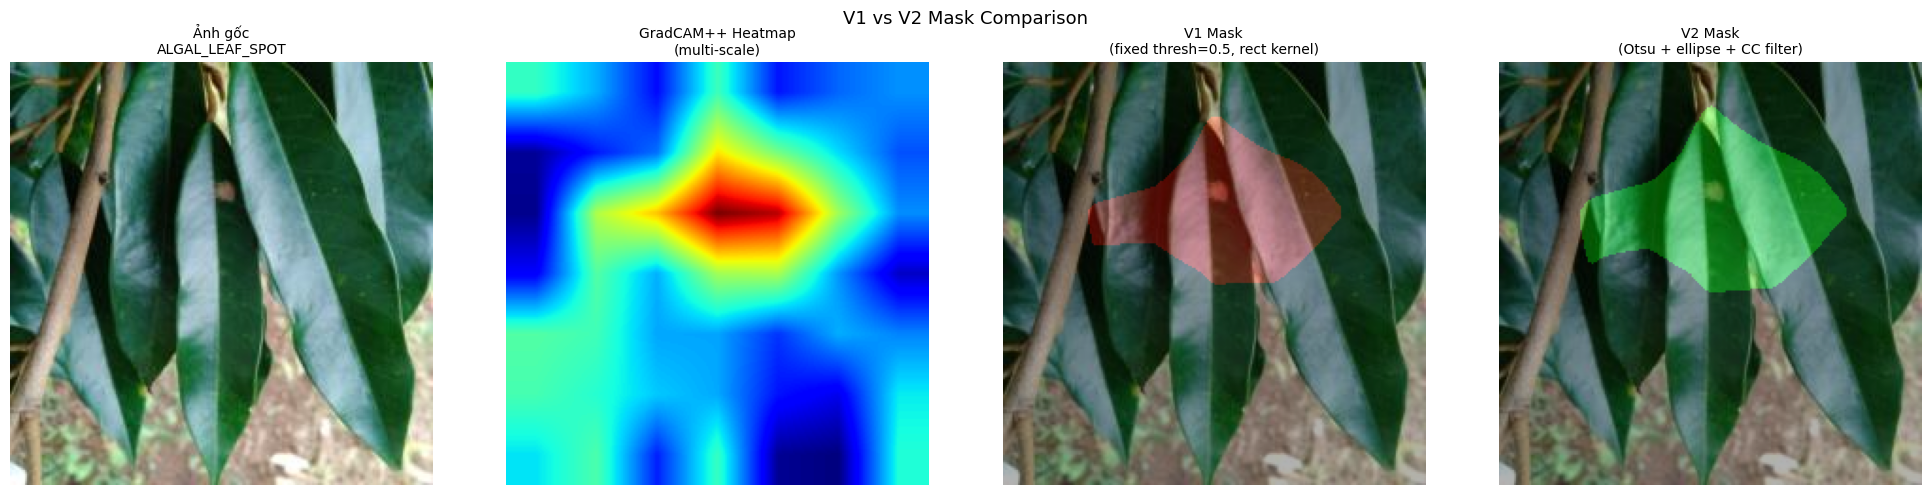

Saved: e:\Master\thesis-clean\models\classification\gradcam\v1_vs_v2_mask_comparison.png


In [17]:
# Demo so sánh v1 threshold (fixed=0.5) vs v2 Otsu trên cùng 1 ảnh
demo_cls   = class_names[0]
demo_items = results_by_class_v2.get(demo_cls, [])

if demo_items:
    demo    = demo_items[0]
    orig    = demo['orig_arr']
    heatmap = demo['heatmap']

    # V1: fixed threshold 0.5
    mask_v1 = (heatmap >= 0.5).astype(np.uint8)
    kernel  = np.ones((5, 5), np.uint8)
    mask_v1 = cv2.morphologyEx(mask_v1, cv2.MORPH_CLOSE, kernel)
    mask_v1 = cv2.morphologyEx(mask_v1, cv2.MORPH_OPEN,  kernel)

    # V2: Otsu + CC filter (đã tính trong demo)
    mask_v2 = demo['mask']

    def overlay_mask(img, mask, color_ch=1):
        rgb = np.zeros_like(img)
        rgb[:, :, color_ch] = mask * 255
        return cv2.addWeighted(img, 0.7, rgb, 0.3, 0)

    fig2, axes2 = plt.subplots(1, 4, figsize=(20, 5))
    axes2[0].imshow(orig)
    axes2[0].set_title(f'Ảnh gốc\n{demo_cls}', fontsize=10)
    axes2[0].axis('off')

    axes2[1].imshow(heatmap, cmap='jet')
    axes2[1].set_title('GradCAM++ Heatmap\n(multi-scale)', fontsize=10)
    axes2[1].axis('off')

    axes2[2].imshow(overlay_mask(orig, mask_v1, color_ch=0))
    axes2[2].set_title('V1 Mask\n(fixed thresh=0.5, rect kernel)', fontsize=10)
    axes2[2].axis('off')

    axes2[3].imshow(overlay_mask(orig, mask_v2, color_ch=1))
    axes2[3].set_title('V2 Mask\n(Otsu + ellipse + CC filter)', fontsize=10)
    axes2[3].axis('off')

    plt.suptitle('V1 vs V2 Mask Comparison', fontsize=13)
    plt.tight_layout()
    save_path2 = os.path.join(out_dir, 'v1_vs_v2_mask_comparison.png')
    plt.savefig(save_path2, dpi=100, bbox_inches='tight')
    plt.show()
    print('Saved:', save_path2)

## 6) Đánh giá chất lượng — so sánh v1 vs v2

In [18]:
import pandas as pd

df_v2 = pd.DataFrame(stats_v2)

# Load v1 stats nếu có
v1_stats_path = os.path.join(proj_root, 'notebooks', 'data', 'pseudo_labels_train',
                              'pseudo_label_stats.json')
if os.path.exists(v1_stats_path):
    with open(v1_stats_path) as f:
        df_v1 = pd.DataFrame(json.load(f))

    print('=' * 55)
    print(f'{"Metric":<25} {"V1 (nb04)":>12} {"V2 (nb07)":>12}')
    print('-' * 55)
    print(f'{"Total samples":<25} {len(df_v1):>12} {len(df_v2):>12}')
    print(f'{"Accuracy (pred==true)":<25} {(df_v1["pred_class"]==df_v1["class_idx"]).mean():>12.2%} '
          f'{(df_v2["pred_class"]==df_v2["class_idx"]).mean():>12.2%}')
    print(f'{"Mean confidence":<25} {df_v1["confidence"].mean():>12.4f} {df_v2["confidence"].mean():>12.4f}')
    print(f'{"Mean mask coverage":<25} {df_v1["mask_coverage"].mean():>12.4f} {df_v2["mask_coverage"].mean():>12.4f}')
    print(f'{"Near-empty masks (<0.05)":<25} {(df_v1["mask_coverage"]<0.05).sum():>12} '
          f'{(df_v2["mask_coverage"]<0.05).sum():>12}')
    print(f'{"Over-large masks (>0.6)":<25} {(df_v1["mask_coverage"]>0.6).sum():>12} '
          f'{(df_v2["mask_coverage"]>0.6).sum():>12}')
    print('=' * 55)
else:
    print('V1 stats không tìm thấy. V2 stats:')

print('\n=== V2 per-class stats ===')
print(df_v2.groupby('class_name')[['confidence', 'mask_coverage']].agg(['mean', 'std']).round(3))

V1 stats không tìm thấy. V2 stats:

=== V2 per-class stats ===
                    confidence        mask_coverage       
                          mean    std          mean    std
class_name                                                
ALGAL_LEAF_SPOT          0.985  0.049         0.265  0.103
ALLOCARIDARA_ATTACK      0.987  0.060         0.270  0.079
HEALTHY_LEAF             0.994  0.019         0.403  0.092
LEAF_BLIGHT              0.985  0.072         0.321  0.112
PHOMOPSIS_LEAF_SPOT      0.967  0.095         0.301  0.105


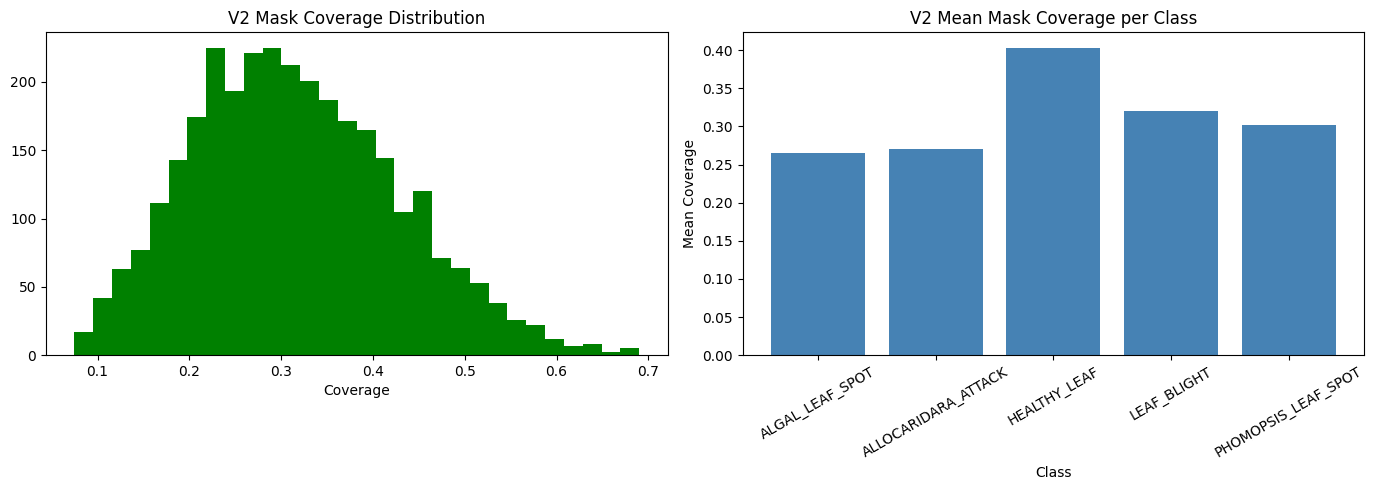

Coverage analysis saved.


In [19]:
# Plot distribution of mask coverage: v1 vs v2
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))

if os.path.exists(v1_stats_path):
    axes3[0].hist(df_v1['mask_coverage'], bins=30, alpha=0.7, label='V1 (fixed 0.5)', color='red')
    axes3[0].hist(df_v2['mask_coverage'], bins=30, alpha=0.7, label='V2 (Otsu)', color='green')
    axes3[0].set_title('Mask Coverage Distribution')
    axes3[0].set_xlabel('Coverage (fraction of image)')
    axes3[0].legend()
else:
    axes3[0].hist(df_v2['mask_coverage'], bins=30, color='green')
    axes3[0].set_title('V2 Mask Coverage Distribution')
    axes3[0].set_xlabel('Coverage')

# Per-class mean coverage
per_cls = df_v2.groupby('class_name')['mask_coverage'].mean()
axes3[1].bar(per_cls.index, per_cls.values, color='steelblue')
axes3[1].set_title('V2 Mean Mask Coverage per Class')
axes3[1].set_xlabel('Class')
axes3[1].set_ylabel('Mean Coverage')
axes3[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'v2_coverage_analysis.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Coverage analysis saved.')